In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

df = pd.read_csv('simple_dataset.csv')

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_review(review):
    review = review.lower()
    review = re.sub(r'[^\w\s]', '', review)
    review = re.sub(r'\d+', '', review)

    tokens = word_tokenize(review)

    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]

    preprocessed_review = ' '.join(lemmatized_tokens)

    return preprocessed_review

In [3]:
df['preprocessed_text'] = df['text'].apply(preprocess_review)
display(df)

,category,text,preprocessed_text
0,Positive,I love this product! It works great and has ex...,love product work great excellent quality
1,Negative,Terrible experience. The product broke after o...,terrible experience product broke one use
2,Positive,Fantastic! I would highly recommend this to ev...,fantastic would highly recommend everyone
3,Negative,Awful. It was a complete waste of money.,awful complete waste money
4,Positive,Amazing product! Very satisfied with my purchase.,amazing product satisfied purchase
5,Negative,Do not buy this. It is not worth the price.,buy worth price


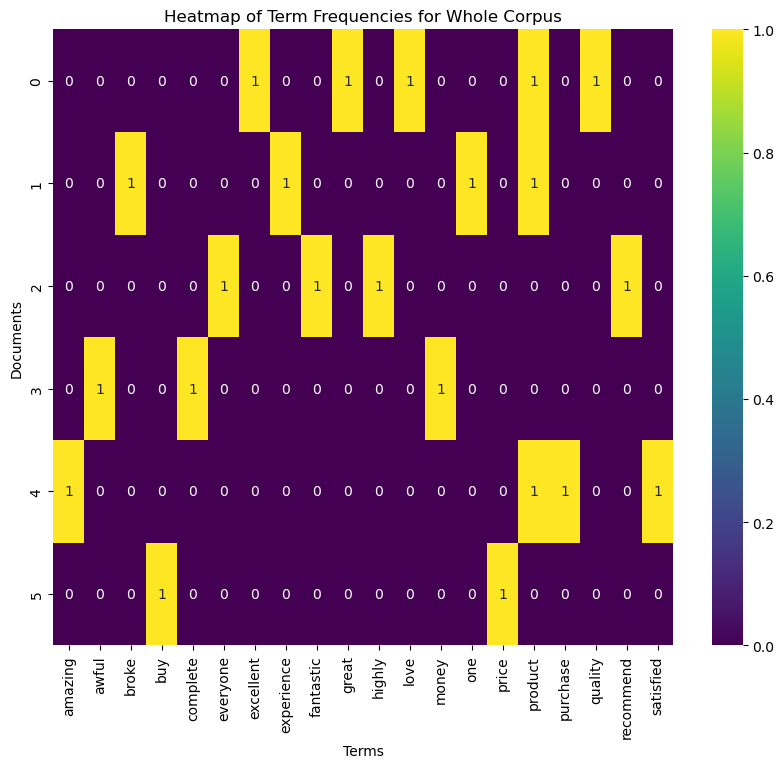

In [4]:
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])

term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, cmap='viridis', annot=True)
plt.title("Heatmap of Term Frequencies for Whole Corpus")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

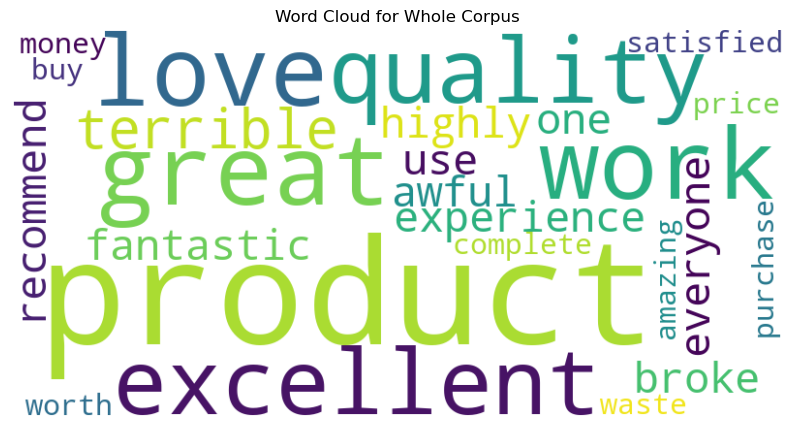

In [5]:
all_text = " ".join(df['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()

In [6]:
positive_text = ' '.join(df[df['category'] == 'Positive']['preprocessed_text'])
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

negative_text = ' '.join(df[df['category'] == 'Negative']['preprocessed_text'])
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

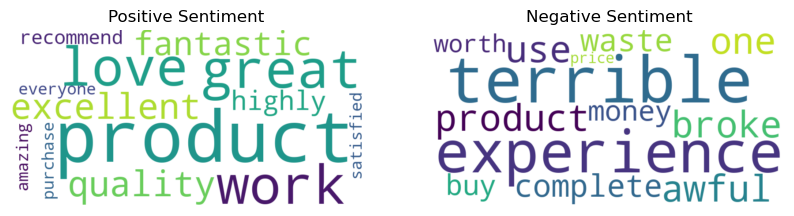

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')

plt.show()

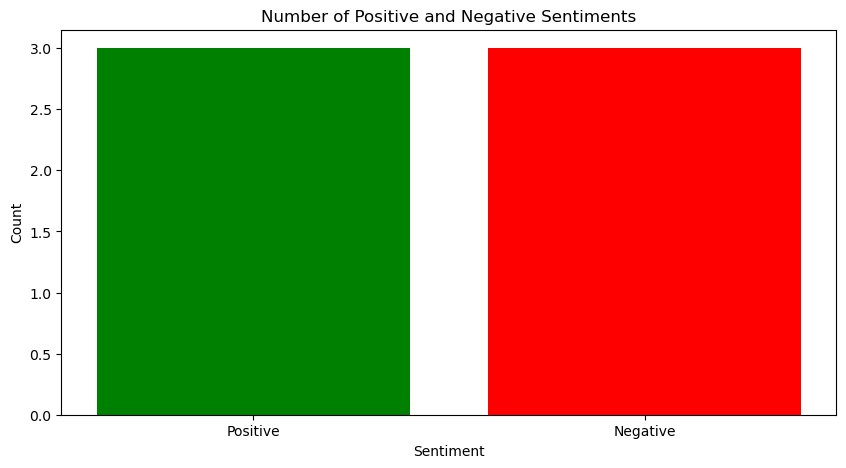

In [8]:
sentiment_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])

plt.title('Number of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Real Dataset**

In [9]:
df = pd.read_csv('restaurant_reviews.csv')